# Aula 8 - Testes Paramétricos

## Motivação

Na Aula 7, construímos a distribuição nula de duas formas: embaralhando
rótulos, no teste de permutação, e por fórmula, no teste *t* de Welch.
Vimos também como ler o *p*-valor, como decidir com $\alpha$ e quais
erros essa decisão pode cometer. Nesta aula, partimos desse ponto e
respondemos a duas perguntas novas. **Quando** a distribuição nula pode
vir de uma fórmula? E, diante de dados de natureza diferente, **qual**
fórmula usar?

Um teste paramétrico troca a simulação por uma curva teórica: *t*, *F*,
*Z* ou $\chi^2$. Essa troca só é segura quando os dados cumprem certas
premissas. A escolha da curva, por sua vez, depende do que medimos e de
como as observações foram coletadas. A primeira parte do roteiro trata
dessas condições. A segunda aplica sete testes a sete problemas reais,
cada um com seu próprio conjunto de dados.

> **Qual teste responde à minha pergunta, e posso confiar nele?**

## Objetivos de aprendizagem

Ao final deste roteiro, você será capaz de:

1.  Explicar o que torna um teste *paramétrico* e o que se ganha e se
    arrisca com ele.
2.  Verificar normalidade, homocedasticidade e independência com Q-Q
    plot, Shapiro-Wilk e o desenho do estudo.
3.  Escolher o teste pelo objetivo, pela escala da variável e pelo
    delineamento.
4.  Aplicar em Python os testes *t* de uma amostra, de Welch e pareado,
    a ANOVA, a correlação de Pearson, o teste *Z* de duas proporções e o
    $\chi^2$ de independência.
5.  Interpretar os resultados e reconhecer quando migrar para um teste
    não paramétrico.

> **Como usar este roteiro**
>
> O roteiro usa cinco conjuntos de dados, cada um salvo em
> `<nome>/data/`:
>
> | Base       | Origem                                            | Casos      |
> |------------|---------------------------------------------------|------------|
> | `mtcars`   | Revista *Motor Trend*, 1974 (já usada na Aula 7)  | 1 e 5      |
> | `penguins` | Pinguins do arquipélago Palmer, Antártida         | 2          |
> | `sleep`    | Ensaio clínico com dois soníferos (Student, 1908) | 3          |
> | `iris`     | Flores de três espécies de íris (Fisher, 1936)    | 4          |
> | `titanic`  | Passageiros do naufrágio do Titanic, 1912         | 2.3, 6 e 7 |
>
> Além das bibliotecas da Aula 7, usamos o `statsmodels` no caso 6.

# 1. Preparando os dados

Começamos com as bibliotecas e as cinco bases. Cada caso usa apenas
algumas colunas, apresentadas quando o caso começar.

In [1]:
# Importa as bibliotecas e define o tema dos gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style="whitegrid", palette="colorblind")

In [2]:
# Carrega as cinco bases
mtcars = pd.read_csv("mtcars/data/mtcars.csv")
penguins = pd.read_csv("penguins/data/penguins.csv")
sleep = pd.read_csv("sleep/data/sleep.csv")
iris = pd.read_csv("iris/data/iris.csv")
titanic = pd.read_csv("titanic/data/titanic.csv")

As cinco bases têm tamanhos bem diferentes, do ensaio clínico com 20
registros ao Titanic com quase 900 passageiros:

| Base       | Linhas | Colunas | Cada linha representa               |
|------------|--------|---------|-------------------------------------|
| `mtcars`   | 32     | 12      | Um modelo de carro                  |
| `penguins` | 344    | 8       | Um pinguim                          |
| `sleep`    | 20     | 3       | Um paciente com uma das duas drogas |
| `iris`     | 150    | 5       | Uma flor                            |
| `titanic`  | 891    | 15      | Um passageiro                       |

O tamanho da amostra influencia diretamente as decisões desta aula. Com
20 registros, a normalidade precisa ser verificada com cuidado. Com
centenas, o teorema central do limite torna o teste *t* robusto, mas o
Shapiro-Wilk passa a rejeitar desvios pequenos.

# 2. O que um teste paramétrico exige

## 2.1 A curva teórica e sua largura

Um teste paramétrico não simula a distribuição nula: ele supõe que os
dados seguem uma família conhecida, como a normal, e lê o *p*-valor como
uma área sob uma curva teórica. No caso de uma média, a estatística e a
largura da curva são:

$$
t = \frac{\bar{x} - \mu_0}{SE}
\qquad\qquad
SE = \frac{s}{\sqrt{n}}
$$

Aqui, $\mu_0$ é o valor de referência sob $H_0$. Sob $H_0$, *t* segue a
distribuição *t* de Student com $n - 1$ graus de liberdade.

O erro-padrão decide se uma diferença é grande ou pequena. Considere a
mesma diferença de 1,5 unidade em duas amostras de 20 observações, uma
com dados pouco dispersos ($SE = 0{,}52$) e outra com dados muito
dispersos ($SE = 1{,}29$). Na
<a href="#fig-same-diff" class="quarto-xref">Figura 1</a>, a diferença
está na mesma posição nos dois painéis. O que muda é a largura da curva
ao redor dela.

Dividindo a diferença pelo erro-padrão, os dois cenários vão para a
mesma régua (<a href="#fig-t-scale" class="quarto-xref">Figura 2</a>). O
primeiro dá $t = 2{,}88$ e cai na região de rejeição
($p \approx 0{,}01$). O segundo dá $t = 1{,}16$ e cai no miolo da curva
($p \approx 0{,}26$).

A diferença é a mesma, mas as conclusões são opostas. E nenhuma das duas
merece confiança se as premissas do teste não valerem.

## 2.2 As três premissas clássicas

Premissas violadas distorcem o erro-padrão e a forma da distribuição
nula. Na prática, o $\alpha$ de 5% deixa de ser 5%.

| Premissa | O que afirma | Se falhar |
|------------------------|------------------------|------------------------|
| **Normalidade** | A resposta, ou os resíduos do modelo, segue uma distribuição normal na população | A distribuição da estatística muda, e o *p*-valor se descalibra em amostras pequenas |
| **Homocedasticidade** | A variância é a mesma em todos os grupos: $\sigma_1^2 = \sigma_2^2 = \dots$ | O erro-padrão combinado fica errado. A solução é a versão de Welch |
| **Independência** | A medida de uma unidade não influencia as demais | Nenhum ajuste de fórmula resolve. É preciso mudar o desenho do teste, por exemplo para o pareado |

A independência é a premissa mais crítica e também a única que não se
verifica olhando os dados: ela depende de **como** foram coletados. A
homocedasticidade se verifica comparando os desvios-padrão dos grupos ou
com o teste de Levene, que aparecerá nos casos 2 e 4. A normalidade tem
ferramentas próprias, apresentadas a seguir.

## 2.3 Verificando a normalidade

Há dois instrumentos complementares:

-   **Diagnóstico gráfico.** O histograma com a curva normal revela
    assimetria, bimodalidade e valores atípicos. O **Q-Q plot** compara
    os quantis da amostra com os quantis esperados de uma normal. Se os
    dados forem normais, os pontos seguem uma reta.
-   **Teste formal.** O **Shapiro-Wilk** testa $H_0$: os dados vêm de
    uma normal. A estatística $W$ varia de 0 a 1, e valores próximos de
    1 indicam forma próxima da normal. Se $p < \alpha$, rejeitamos a
    normalidade.

O gráfico mostra **como** os dados fogem da normal. O teste diz **se** o
desvio é maior que o esperado pelo acaso. Cada forma de distribuição
deixa uma assinatura típica no Q-Q plot:

| Forma da distribuição | Assinatura no Q-Q plot |
|------------------------------------|------------------------------------|
| Normal | Pontos sobre a reta |
| Assimetria à direita | Curva em U: as duas pontas acima da reta |
| Assimetria à esquerda | Arco (∩): as duas pontas abaixo da reta |
| Caudas pesadas | Forma de S: as pontas fogem da reta em sentidos opostos |
| Caudas leves | S invertido: as pontas achatadas |
| Bimodal | Degrau no meio: faltam observações no centro |

Vejamos dois casos reais: o consumo dos carros do `mtcars` e o preço das
passagens do Titanic.

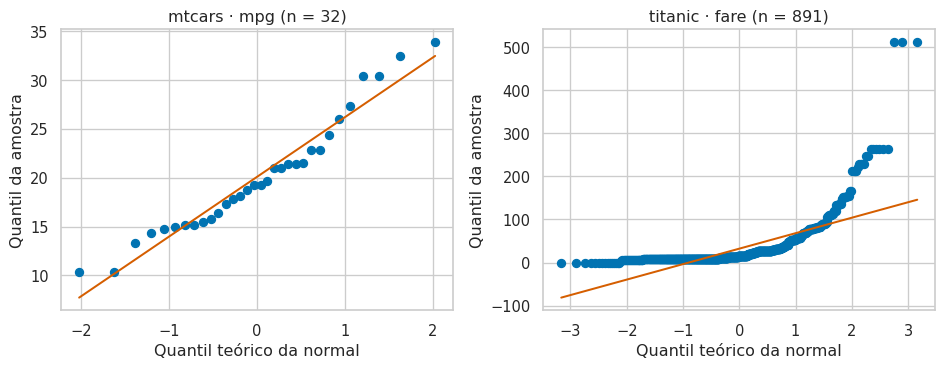

In [5]:
# Q-Q plot e Shapiro-Wilk em duas variáveis reais
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, values, title in zip(
    axes,
    [mtcars["mpg"], titanic["fare"]],
    ["mtcars · mpg (n = 32)", "titanic · fare (n = 891)"],
):
    stats.probplot(values, dist="norm", plot=ax)
    ax.set(title=title, xlabel="Quantil teórico da normal",
           ylabel="Quantil da amostra")

plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "mpg": stats.shapiro(mtcars["mpg"]),
        "fare": stats.shapiro(titanic["fare"]),
    },
    index=["W", "p"],
).T

Os dois diagnósticos concordam. No `mtcars`, os pontos seguem a reta,
com um leve afastamento só na cauda direita. O Shapiro-Wilk dá
$W \approx 0{,}95$ e $p \approx 0{,}12$: não rejeitamos a normalidade.
No Titanic, o Q-Q plot forma uma curva acentuada, a assinatura de forte
assimetria à direita. Algumas tarifas ficam quase 10 desvios-padrão
acima da média. O teste dá $W \approx 0{,}52$ e um *p*-valor
praticamente zero.

> **Cuidado com o tamanho da amostra**
>
> Com *n* pequeno, o Shapiro-Wilk tem pouco poder e deixa passar desvios
> importantes. Com *n* grande, rejeita desvios irrelevantes. Por isso, a
> decisão nunca deve se apoiar só no *p*-valor do teste: olhe sempre o
> Q-Q plot. Lembre também que, pelo teorema central do limite, com
> amostras moderadas ou grandes o que precisa ser aproximadamente normal
> é a **média**, não cada observação.

## 2.4 O tipo de variável

Saber a forma da distribuição não basta. O teste também depende de **o
que** medimos. A escala da variável resposta define quais operações
fazem sentido e, portanto, quais testes podem ser aplicados:

| Tipo | Exemplo | Operações permitidas |
|------------------------|------------------------|------------------------|
| Numérica contínua | Consumo em mpg (`mtcars`) | Média, desvio-padrão, todas as operações |
| Numérica discreta | Número de carburadores (`mtcars`): 1, 2, 3, 4, 6 ou 8 | Contagem, ordem, mediana, moda. Média com cautela |
| Categórica binária | Sobreviveu ou não (`titanic`) | Frequência e proporção |
| Categórica ordinal | Escala Likert de 1 a 5, escolaridade | Ordenação, mediana, percentis |
| Categórica nominal | Espécie (`iris`, `penguins`), classe da cabine (`titanic`) | Contagem, moda, tabela de contingência |

Em uma variável ordinal, há ordem entre os níveis, mas a distância entre
eles não é medida diretamente. Tratar uma escala Likert como contínua,
sem justificativa, invalida o cálculo do erro-padrão.

## 2.5 Amostras independentes ou pareadas

O teste depende ainda de **como** as observações foram coletadas:

|  | Independentes | Pareadas (dependentes) |
|------------------------|------------------------|------------------------|
| Exemplo | Massa de pinguins machos e fêmeas (`penguins`) | Sono dos mesmos pacientes com duas drogas (`sleep`) |
| Foco | Diferença entre médias: $\bar{x}_1 - \bar{x}_2$ | Média das diferenças individuais: $D = X_2 - X_1$ |
| Erro-padrão | Carrega a variação entre indivíduos | O pareamento cancela a variação de base de cada indivíduo |
| Poder | Menor, para o mesmo *n* | Maior: isola o efeito do tratamento |

A pergunta-chave é: **saber o valor de uma observação diz algo sobre uma
observação do outro grupo?** Se sim, as amostras são pareadas. O caso 3
mostra o que acontece quando essa estrutura é ignorada.

## 2.6 Três perguntas escolhem o teste

A escolha do teste resulta de três perguntas, feitas nesta ordem:

1.  **Qual o objetivo?** Comparar médias, comparar proporções ou medir
    associação.
2.  **Qual a escala?** Da resposta e da variável explicativa: contínua,
    binária ou nominal.
3.  **Qual o desenho?** Uma amostra, dois grupos ou três ou mais;
    independentes ou pareados.

Respondidas as três, o teste fica determinado, e resta verificar suas
premissas. A matriz abaixo resume os sete casos desta aula:

| Objetivo | Resposta | Explicativa e desenho | Teste | Caso |
|---------------|---------------|---------------|---------------|---------------|
| Média contra uma meta | Contínua | Nenhuma (valor $\mu_0$) | *t* de uma amostra | 1 · `mtcars` |
| Médias de 2 grupos | Contínua | Binária, independentes | *t* de Welch | 2 · `penguins` |
| Antes e depois | Contínua | 2 momentos, pareados | *t* pareado | 3 · `sleep` |
| Médias de 3 ou mais grupos | Contínua | Nominal, independentes | ANOVA + Tukey | 4 · `iris` |
| Associação linear | Contínua | Contínua | Pearson | 5 · `mtcars` |
| Proporções de 2 grupos | Binária | Binária, independentes | *Z* de duas proporções | 6 · `titanic` |
| Associação entre categorias | Nominal | Nominal, independentes | Qui-quadrado | 7 · `titanic` |

Errar a escolha, por exemplo usando um teste para amostras independentes
em dados pareados, ou vários testes *t* no lugar da ANOVA, altera as
taxas de erro dos tipos I e II.

## 2.7 Intervalo de confiança

Outro conceito importante é o **intervalo de confiança**. Assim como o
*p*-valor responde se um valor específico, o de $H_0$, é compatível com
os dados. O **intervalo de confiança** delimita: que valores do
parâmetro são compatíveis com os dados. Em uma média, ele é construído a
partir da estimativa e do erro-padrão:

$$
\bar{x} \pm t_{crit} \cdot SE
$$

Aqui, $t_{crit}$ é o valor crítico da distribuição *t* com $n - 1$ graus
de liberdade, cerca de 2 para amostras moderadas. No caso 1, por
exemplo, a média de 20,09 mpg, com erro-padrão de 1,07 mpg e
$t_{crit} = 2{,}04$, gera o intervalo de 95% de 17,9 a 22,3 mpg.

Três pontos orientam a leitura:

-   **Interpretação.** O “95%” descreve o método, não um intervalo
    específico. Se repetíssemos a coleta muitas vezes, 95% dos
    intervalos construídos dessa forma conteriam o valor verdadeiro do
    parâmetro. Não é correto dizer que há 95% de probabilidade de a
    média estar dentro de um intervalo já calculado.
-   **Largura.** O intervalo é mais estreito quando o erro-padrão é
    menor: com mais dados ou dados menos dispersos, a estimativa fica
    mais precisa.
-   **Ligação com o teste.** Um intervalo de 95% que **não contém** o
    valor de $H_0$ equivale a rejeitar $H_0$ com $\alpha = 0{,}05$ em um
    teste bilateral. Se o contém, não rejeitamos. A vantagem do
    intervalo é mostrar também o tamanho do efeito e a incerteza sobre
    ele.

Nos casos a seguir, o intervalo é obtido com o método
`.confidence_interval()`, disponível nos resultados dos testes *t* e da
correlação de Pearson.

# 3. Sete casos, sete testes

Cada caso segue o mesmo roteiro: o cenário com as hipóteses, em
destaque, as premissas do teste, o cálculo passo a passo, a verificação
das premissas nos dados, o gráfico e a interpretação.

Antes de mais nada, as funções de teste do SciPy e do `statsmodels`
devolvem objetos com vários campos, como
`TtestResult(statistic=..., pvalue=..., df=...)`. Para ler os resultados
com mais facilidade, usamos ao longo da aula uma função que resume cada
teste em uma única linha:

In [6]:
# Resume o resultado de um teste em uma linha legível
def report(name, result, stat="estatística", df=None):
    if isinstance(result, tuple):
        value, p = result
    else:
        value, p = result.statistic, result.pvalue
    df = df if df is not None else getattr(result, "df", None)

    parts = [f"{stat} = {value:.3f}"]
    if df is not None:
        parts.append(f"gl = {df:.4g}" if np.isscalar(df) else f"gl = {df}")
    parts.append("p < 0.001" if p < 0.001 else f"p = {p:.3f}")
    if hasattr(result, "confidence_interval"):
        ci = result.confidence_interval()
        parts.append(f"IC 95% [{ci.low:.2f} ; {ci.high:.2f}]")

    print(f"{name}: " + " · ".join(parts))

## Caso 1. Teste *t* de uma amostra

> **Cenário**
>
> A gestão de uma frota pergunta se o consumo médio (`mpg`) dos veículos
> atende à meta de projeto de 20 mpg. Você tem os dados de 32 carros: a
> média deles basta para responder?
>
> -   $H_0$: o consumo médio é igual à meta ($\mu = 20$).
> -   $H_1$: o consumo médio é diferente da meta ($\mu \neq 20$).

**Premissas do teste**

-   Observações independentes entre si.
-   Variável resposta numérica contínua.
-   Distribuição normal na população ou amostra grande o bastante para
    que a média seja aproximadamente normal, pelo teorema central do
    limite.

Calculamos a estatística passo a passo, seguindo as fórmulas da seção
2.1:

In [7]:
# Teste t de uma amostra, passo a passo
mpg = mtcars["mpg"]
target = 20

n = len(mpg)
se = mpg.std() / np.sqrt(n)
t = (mpg.mean() - target) / se
p = 2 * stats.t.sf(abs(t), df=n - 1)

In [8]:
print(f"média       = {mpg.mean():.3f}")
print(f"dp          = {mpg.std():.3f}")
print(f"erro-padrão = {se:.3f}")
print(f"t           = {t:.3f}")
print(f"gl          = {n - 1}")
print(f"p           = {p:.3f}")

média       = 20.091
dp          = 6.027
erro-padrão = 1.065
t           = 0.085
gl          = 31
p           = 0.933

A média da frota, 20,09 mpg, fica só 0,09 mpg acima da meta. Como o
erro-padrão é de 1,07 mpg, a diferença equivale a menos de um décimo de
erro-padrão. A função do SciPy confirma o resultado e fornece o
intervalo de confiança de 95% para a média:

In [9]:
# Teste t de uma amostra com o SciPy
case1 = stats.ttest_1samp(mpg, popmean=target)

report("t de uma amostra", case1, stat="t")

t de uma amostra: t = 0.085 · gl = 31 · p = 0.933 · IC 95% [17.92 ; 22.26]

O intervalo de confiança contém os valores de média compatíveis com os
dados.

Quanto às premissas, os carros são modelos distintos, e a seção 2.3 já
mostrou que o consumo passa no Shapiro-Wilk ($p \approx 0{,}12$).

O gráfico mostra os carros, a média e o intervalo em relação à meta. A
mesma visualização será usada no caso 3, por isso fica em uma função:

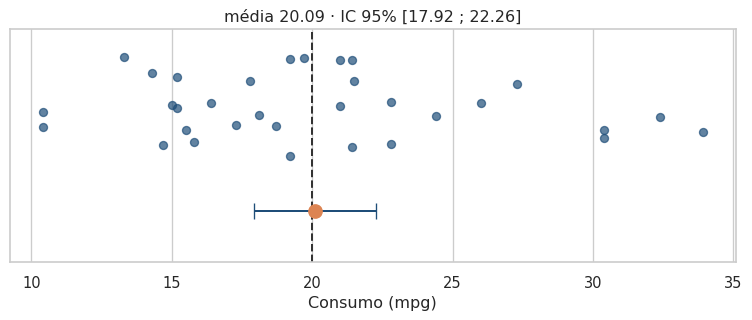

In [10]:
# Pontos, média e intervalo de confiança em relação a um valor de referência
def plot_mean_ci(values, ci, ref, xlabel, ax):
    jitter = np.random.default_rng(1).uniform(0.6, 1.4, len(values))
    ax.scatter(values, jitter, color="#1F4E79", alpha=.7)
    error = [[values.mean() - ci.low], [ci.high - values.mean()]]
    ax.errorbar(values.mean(), 0.2, xerr=error, fmt="o", color="#DD8452",
                ecolor="#1F4E79", capsize=6, markersize=10)
    ax.axvline(ref, color="#333333", linestyle="--")
    ax.set(xlabel=xlabel, yticks=[], ylim=(-0.2, 1.6),
           title=f"média {values.mean():.2f} · IC 95% [{ci.low:.2f} ; {ci.high:.2f}]")

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_mean_ci(mpg, case1.confidence_interval(), target, "Consumo (mpg)", ax)
plt.tight_layout()
plt.show()

**Interpretação.** Os carros se espalham dos dois lados da meta, de 10 a
34 mpg. A média (ponto laranja) cai praticamente sobre a linha
tracejada, e o intervalo de confiança, de 17,9 a 22,3 mpg, contém a meta
com folga. Se a média real da frota fosse 20 mpg, diferenças iguais ou
maiores que a observada surgiriam em 93% das amostras
($p \approx 0{,}93$). Não rejeitamos $H_0$: não há evidência de que a
frota esteja fora da meta. Isso, porém, não prova que $\mu = 20$. Os
dados são apenas compatíveis com a meta, como também seriam com qualquer
valor dentro do intervalo.

## Caso 2. Teste *t* de Welch

> **Cenário**
>
> Uma equipe de biólogos de campo quer saber se machos e fêmeas de
> pinguins têm massas corporais (`body_mass`, em gramas) médias
> diferentes, um sinal de dimorfismo sexual. Cada grupo é formado por
> animais distintos.
>
> -   $H_0$: machos e fêmeas têm, em média, a mesma massa
>     ($\mu_1 = \mu_2$).
> -   $H_1$: as massas médias são diferentes ($\mu_1 \neq \mu_2$).

**Premissas do teste**

-   Observações independentes, dentro de cada grupo e entre os grupos.
-   Variável resposta numérica contínua.
-   Distribuição normal em cada grupo ou amostras grandes o bastante
    para o teorema central do limite.
-   As variâncias dos grupos **não** precisam ser iguais. É isso que
    distingue a versão de Welch do teste *t* clássico.

A base tem 344 pinguins, mas 11 não têm o sexo registrado. Ficamos com
os 333 restantes:

In [11]:
# Pinguins com sexo e massa registrados
penguins_sex = penguins.dropna(subset=["sex", "body_mass"])

males = penguins_sex.loc[penguins_sex["sex"] == "male", "body_mass"]
females = penguins_sex.loc[penguins_sex["sex"] == "female", "body_mass"]

O teste de Welch usa a variância de cada grupo separadamente. A tabela
traz a parcela $s^2/n$ de cada um, que mede a incerteza da média do
grupo:

In [12]:
# Resumo por grupo e parcelas do erro-padrão de Welch
welch_table = (
    penguins_sex
    .groupby("sex")
    .body_mass
    .agg(n="size", média="mean", dp="std")
    .assign(s2_n=lambda df: df["dp"] ** 2 / df["n"])
)

welch_table.round(1)

In [13]:
# Erro-padrão da diferença, estatística t e teste de Welch
se_diff = np.sqrt(welch_table["s2_n"].sum())
t_manual = (males.mean() - females.mean()) / se_diff

case2 = stats.ttest_ind(males, females, equal_var=False)

print(f"erro-padrão da diferença = {se_diff:.1f} g")
print(f"t calculado à mão = {t_manual:.2f}")
report("t de Welch", case2, stat="t")

erro-padrão da diferença = 79.9 g
t calculado à mão = 8.55
t de Welch: t = 8.555 · gl = 323.9 · p < 0.001 · IC 95% [526.25 ; 840.58]

Os machos pesam, em média, 4.546 g, e as fêmeas, 3.862 g: uma diferença
de 683 g. O erro-padrão da diferença é de cerca de 80 g, e a diferença
cabe 8,55 vezes nele. Os graus de liberdade, cerca de 324, vêm da
correção de Welch-Satterthwaite, que ajusta a curva *t* quando as
variâncias diferem.

Com mais de 160 animais por grupo, o teorema central do limite garante a
normalidade das médias. E as variâncias, diferem? O teste de Levene
verifica a homocedasticidade:

In [14]:
# Homocedasticidade, intervalo da diferença e sobreposição dos grupos
ci = case2.confidence_interval()

print(f"Levene: p = {stats.levene(males, females).pvalue:.3f}")
print(f"IC 95% da diferença: [{ci.low:.0f} ; {ci.high:.0f}] g")
print(f"fêmeas acima do macho médio: {(females > males.mean()).mean():.0%}")

Levene: p = 0.014
IC 95% da diferença: [526 ; 841] g
fêmeas acima do macho médio: 25%

O desvio-padrão dos machos (788 g) é maior que o das fêmeas (666 g), e o
Levene rejeita a igualdade de variâncias ($p \approx 0{,}014$). Esse é o
motivo para usar a versão de Welch. O intervalo de confiança de 95% da
diferença vai de 526 a 841 g, longe de zero.

O gráfico mostra cada pinguim e a média de cada grupo. Ele será
reutilizado no caso 4, por isso fica em uma função:

In [15]:
# Observações e média de cada grupo
def plot_group_means(data, x, y, order, ylabel, ax):
    sns.stripplot(data=data, x=x, y=y, order=order, ax=ax,
                  color="#1F4E79", alpha=.5, jitter=.25)
    means = data.groupby(x)[y].mean().reindex(order)
    ax.hlines(means, np.arange(len(order)) - .35, np.arange(len(order)) + .35,
              color="#DD8452", linewidth=3)
    ax.set(xlabel="", ylabel=ylabel)

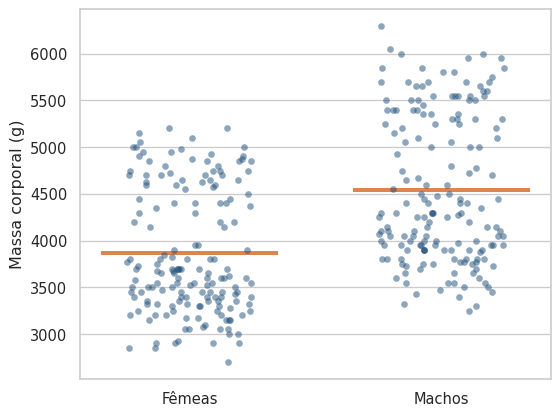

In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_group_means(penguins_sex, "sex", "body_mass", ["female", "male"],
                 "Massa corporal (g)", ax)
ax.set_xticks([0, 1], ["Fêmeas", "Machos"])
plt.tight_layout()
plt.show()

**Interpretação.** Os dois grupos se sobrepõem bastante: cerca de 25%
das fêmeas pesam mais que o macho médio. Ainda assim, a média dos machos
fica bem acima da média das fêmeas. Se machos e fêmeas tivessem a mesma
massa média, uma diferença de 683 g seria praticamente impossível por
acaso ($p < 0{,}001$). Rejeitamos $H_0$: há evidência de dimorfismo
sexual, com machos mais pesados. Note que o teste fala de **médias**.
Ele não afirma que todo macho é mais pesado que toda fêmea.

## Caso 3. Teste *t* pareado

> **Cenário**
>
> Em um ensaio clínico, os mesmos 10 pacientes testaram dois soníferos,
> um em cada período, e foram medidas as horas extras de sono (`extra`).
> O médico quer saber se a droga 2 rende mais horas de sono que a droga
> 1.
>
> -   $H_0$: em média, a droga 2 não muda as horas de sono em relação à
>     droga 1 ($\mu_D = 0$).
> -   $H_1$: em média, as horas de sono mudam entre as drogas
>     ($\mu_D \neq 0$).

**Premissas do teste**

-   Cada par de medidas vem da mesma unidade, no caso o mesmo paciente.
-   Os pares são independentes entre si.
-   Variável resposta numérica contínua.
-   As diferenças dentro de cada par, $D_i = X_{2i} - X_{1i}$, seguem
    aproximadamente uma distribuição normal.

A base `sleep` está no formato longo: uma linha por paciente e droga.
Reorganizamos para uma linha por paciente e calculamos a diferença:

In [17]:
# Uma linha por paciente, com a diferença entre as drogas
sleep_wide = (
    sleep
    .pivot(index="ID", columns="group", values="extra")
    .rename(columns={1: "droga_1", 2: "droga_2"})
    .assign(D=lambda df: df["droga_2"] - df["droga_1"])
)

sleep_wide

A partir daqui, as colunas originais saem de cena. O teste pareado é um
teste *t* de uma amostra sobre a coluna `D`, com $\mu_0 = 0$:

$$
t = \frac{\bar{D} - 0}{s_D / \sqrt{n}}
$$

In [18]:
# Teste t pareado e o mesmo teste ignorando o pareamento
case3 = stats.ttest_rel(sleep_wide["droga_2"], sleep_wide["droga_1"])
unpaired = stats.ttest_ind(sleep_wide["droga_2"], sleep_wide["droga_1"])

pd.DataFrame(
    {"t": [case3.statistic, unpaired.statistic], "p": [case3.pvalue, unpaired.pvalue]},
    index=["pareado", "ignorando o pareamento"],
).round(4)

A média das diferenças é de 1,58 h, com desvio-padrão de 1,23 h. O teste
pareado dá $t = 4{,}06$ com 9 graus de liberdade e $p \approx 0{,}003$.
Com os **mesmos dados**, tratados como dois grupos independentes, o
*p*-valor sobe para 0,079, e a diferença deixa de ser significante.

O motivo aparece no gráfico. À esquerda, cada linha liga as duas medidas
de um paciente. À direita, cada ponto é a diferença de um paciente, com
a média e o intervalo de confiança:

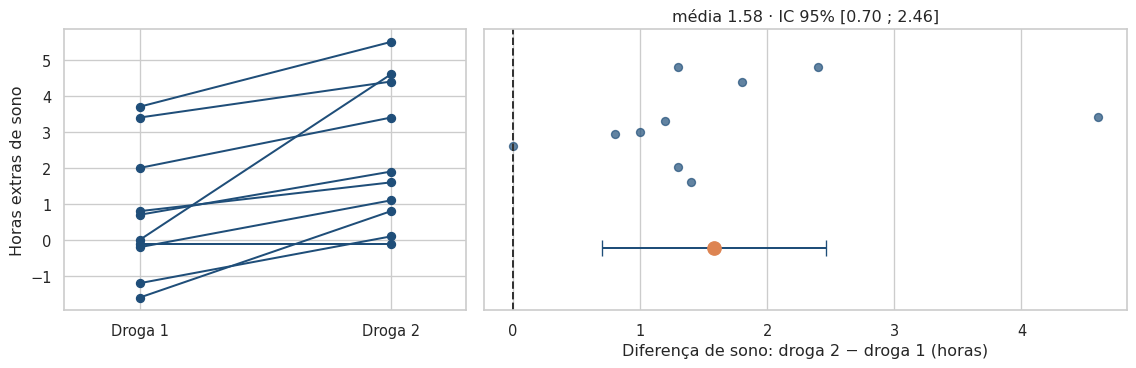

In [19]:
# Linhas por paciente e diferenças com intervalo de confiança
fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1.6])

axes[0].plot([0, 1], sleep_wide[["droga_1", "droga_2"]].T, color="#1F4E79", marker="o")
axes[0].set(xticks=[0, 1], xticklabels=["Droga 1", "Droga 2"], xlim=(-.3, 1.3),
            ylabel="Horas extras de sono")

plot_mean_ci(sleep_wide["D"], case3.confidence_interval(), 0,
             "Diferença de sono: droga 2 − droga 1 (horas)", axes[1])
plt.tight_layout()
plt.show()

Os pacientes são muito diferentes entre si: alguns dormem bem com
qualquer droga, outros dormem pouco. A correlação entre as duas medidas
de cada paciente é de cerca de 0,80. Vistos como dois grupos soltos, os
pontos se misturam, e a variação **entre pacientes** esconde o efeito.
Olhando paciente a paciente, o padrão aparece: as linhas sobem em 9 dos
10 casos, e nenhum paciente piora. O pareamento cancela a variação de
base de cada pessoa e isola o efeito da droga.

Há, porém, uma ressalva. Com apenas 10 diferenças, a normalidade pesa
mais:

In [20]:
# Normalidade das diferenças e alternativa não paramétrica
report("Shapiro-Wilk das diferenças", stats.shapiro(sleep_wide["D"]), stat="W")
report("Wilcoxon", stats.wilcoxon(sleep_wide["D"]), stat="T")

Shapiro-Wilk das diferenças: W = 0.830 · p = 0.033
Wilcoxon: T = 0.000 · p = 0.004

O Shapiro-Wilk rejeita a normalidade das diferenças
($p \approx 0{,}03$), em boa parte por causa do paciente com ganho de
4,6 h. O teste de Wilcoxon dos postos sinalizados, a alternativa não
paramétrica ao *t* pareado, chega à mesma conclusão
($p \approx 0{,}004$).

**Interpretação.** Quase todos os pacientes estão à direita da linha de
zero, e o intervalo da média, de 0,70 a 2,46 h, não toca nela. Se as
duas drogas fossem equivalentes, um ganho médio de 1,58 h surgiria em
apenas 0,3% dos ensaios. Rejeitamos $H_0$: nos mesmos pacientes, a droga
2 rende em média cerca de 1,6 h a mais de sono que a droga 1.

## Caso 4. ANOVA one-way

> **Cenário**
>
> Um botânico mede flores de três espécies de íris e quer saber se o
> comprimento médio da sépala (`sepal_length`) é o mesmo nas três, antes
> de usá-lo para diferenciá-las.
>
> -   $H_0$: as três espécies têm o mesmo comprimento médio
>     ($\mu_1 = \mu_2 = \mu_3$).
> -   $H_1$: pelo menos uma espécie tem média diferente.

**Premissas do teste**

-   Observações independentes, dentro de cada grupo e entre os grupos.
-   Variável resposta numérica contínua.
-   Resíduos aproximadamente normais em cada grupo.
-   Variâncias iguais entre os grupos (homocedasticidade).

Por que não comparar as espécies duas a duas com três testes *t*? Porque
cada teste tem 5% de chance de falso positivo, e a chance de errar pelo
menos uma vez cresce com o número de comparações, como vimos na seção
6.2 da Aula 7. Com $k$ grupos, há $k(k-1)/2$ pares: 3 pares para 3
grupos, 10 para 5. A ANOVA responde à pergunta com **um único teste** e
mantém o $\alpha$ em 5%.

A ideia da ANOVA é comparar duas fontes de variação. Se as médias das
espécies se afastam muito da média geral, em relação à variação natural
dentro de cada espécie, a estatística *F* fica grande:

$$
F = \frac{MQG}{MQR} = \frac{SQG / (k - 1)}{SQR / (N - k)}
$$

Aqui, $SQG$ é a soma de quadrados **entre** grupos, $SQR$ a soma de
quadrados **dentro** dos grupos (resíduos), $k$ o número de grupos e $N$
o total de observações. Calculamos a tabela da ANOVA passo a passo:

In [21]:
# Tabela da ANOVA calculada passo a passo
grand_mean = iris["sepal_length"].mean()

by_species = (
    iris
    .groupby("species")
    .sepal_length
    .agg(n="size", média="mean", dp="std")
)

ss_between = (by_species["n"] * (by_species["média"] - grand_mean) ** 2).sum()

ss_within = ((by_species["n"] - 1) * by_species["dp"] ** 2).sum()

k, N = len(by_species), len(iris)

In [22]:
pd.DataFrame(
    {"SQ": [ss_between, ss_within], "gl": [k - 1, N - k]},
    index=["entre espécies", "dentro (resíduos)"],
).assign(MQ=lambda df: df["SQ"] / df["gl"]).round(3)

O quadrado médio entre espécies (31,61) é cerca de 119 vezes o quadrado
médio dentro das espécies (0,265). Conferimos com o SciPy e, como a
ANOVA só diz que **alguma** média difere, usamos o teste de Tukey para
descobrir **quais**:

In [23]:
# ANOVA, comparações de Tukey e homocedasticidade
setosa, versicolor, virginica = [
    group["sepal_length"] for _, group in iris.groupby("species")
]

anova = stats.f_oneway(setosa, versicolor, virginica)

report("ANOVA", anova, stat="F", df=(k - 1, N - k))
report("Levene", stats.levene(setosa, versicolor, virginica))
print(stats.tukey_hsd(setosa, versicolor, virginica))

ANOVA: F = 119.265 · gl = (2, 147) · p < 0.001
Levene: estatística = 6.353 · p = 0.002
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.930     0.000    -1.174    -0.686
 (0 - 2)     -1.582     0.000    -1.826    -1.338
 (1 - 0)      0.930     0.000     0.686     1.174
 (1 - 2)     -0.652     0.000    -0.896    -0.408
 (2 - 0)      1.582     0.000     1.338     1.826
 (2 - 1)      0.652     0.000     0.408     0.896


A ANOVA dá $F \approx 119{,}3$ com $(2, 147)$ graus de liberdade e
$p < 0{,}001$. O Tukey indica que os três pares diferem, com diferenças
de 0,65 a 1,58 cm e todos os *p*-valores abaixo de 0,001. A fração da
variação total explicada pela espécie, $\eta^2 = SQG / (SQG + SQR)$, é
de cerca de 0,62.

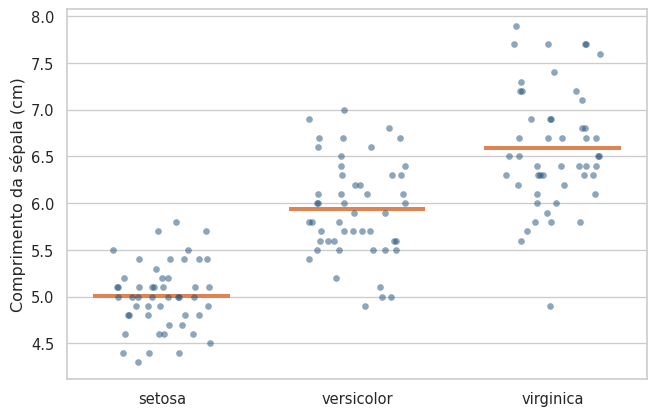

In [24]:
# Comprimento da sépala por espécie
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_group_means(iris, "species", "sepal_length", ["setosa", "versicolor", "virginica"],
                 "Comprimento da sépala (cm)", ax)
plt.tight_layout()
plt.show()

**Interpretação.** As médias sobem de setosa (5,01 cm) para versicolor
(5,94 cm) e virginica (6,59 cm), e a distância entre elas é grande em
relação à dispersão dentro de cada espécie. Se as espécies tivessem a
mesma sépala média, diferenças desse tamanho seriam praticamente
impossíveis por acaso. Rejeitamos $H_0$: o comprimento da sépala
distingue as três espécies, e todos os pares diferem entre si.

Fica uma ressalva. O teste de Levene rejeita a igualdade de variâncias
($p \approx 0{,}002$): a dispersão cresce de setosa para virginica.
Nesse caso, uma alternativa mais segura é a ANOVA de Welch, seguida do
teste de Games-Howell. Com diferenças tão grandes, a conclusão não muda.

## Caso 5. Correlação de Pearson

> **Cenário**
>
> Um engenheiro quer entender se carros mais pesados (`wt`, em milhares
> de libras) tendem a gastar mais combustível (`mpg`), e quão forte é
> essa relação, antes de propor um projeto mais leve.
>
> -   $H_0$: não há relação linear entre peso e consumo ($\rho = 0$).
> -   $H_1$: existe relação linear entre peso e consumo ($\rho \neq 0$).

**Premissas do teste**

-   Pares de observações independentes entre si.
-   As duas variáveis são numéricas contínuas.
-   A relação entre elas é linear.
-   Normalidade bivariada e ausência de valores atípicos influentes.

O coeficiente de Pearson mede o quanto duas variáveis numéricas andam
juntas **em linha reta**. O numerador soma os produtos dos desvios: é
positivo quando valores altos de uma variável acompanham valores altos
da outra. O denominador padroniza o resultado e o prende entre $-1$ e
$+1$:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}
$$

In [25]:
# Coeficiente de Pearson pela fórmula e pelo SciPy
dx = mtcars["wt"] - mtcars["wt"].mean()
dy = mtcars["mpg"] - mtcars["mpg"].mean()

r_manual = (dx * dy).sum() / np.sqrt((dx ** 2).sum() * (dy ** 2).sum())
case5 = stats.pearsonr(mtcars["wt"], mtcars["mpg"])

print(f"r calculado à mão = {r_manual:.3f}")
report("Pearson", case5, stat="r")

r calculado à mão = -0.868
Pearson: r = -0.868 · p < 0.001 · IC 95% [-0.93 ; -0.74]

O coeficiente vale $r \approx -0{,}87$, com $p < 0{,}001$. O sinal
negativo indica a direção: mais peso, menos milhas por galão. O tamanho
indica a força. Como referência, valores de $|r|$ abaixo de 0,3 costumam
ser descritos como fracos, entre 0,3 e 0,5 como moderados e acima de 0,5
como fortes.

O coeficiente tem duas propriedades úteis. Ele é **simétrico**:
$r(\text{peso}, \text{consumo}) = r(\text{consumo}, \text{peso})$. E é
**invariante** a mudanças de unidade. Convertendo o peso para
quilogramas, o resultado não muda:

In [26]:
# O coeficiente não depende da unidade de medida
r_kg = stats.pearsonr(mtcars["wt"] * 453.6, mtcars["mpg"]).statistic

print(f"r com o peso em kg = {r_kg:.3f}")

r com o peso em kg = -0.868

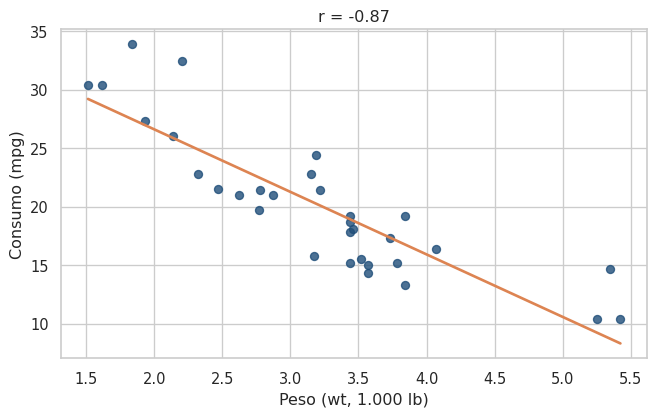

In [27]:
# Consumo versus peso, com a reta de mínimos quadrados
slope, intercept = np.polyfit(mtcars["wt"], mtcars["mpg"], deg=1)
grid = np.linspace(mtcars["wt"].min(), mtcars["wt"].max(), 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(mtcars["wt"], mtcars["mpg"], color="#1F4E79", alpha=.8)
ax.plot(grid, intercept + slope * grid, color="#DD8452", linewidth=2)
ax.set(title=f"r = {case5.statistic:.2f}", xlabel="Peso (wt, 1.000 lb)",
       ylabel="Consumo (mpg)")
plt.tight_layout()
plt.show()

**Interpretação.** Os pontos descem da esquerda para a direita e ficam
próximos da reta. Se peso e consumo não tivessem relação linear, um *r*
tão forte seria praticamente impossível por acaso. Rejeitamos $H_0$:
carros mais pesados tendem a fazer menos milhas por galão.

Dois limites merecem atenção. Pearson só enxerga relações **lineares**:
uma relação em forma de U pode ter $r \approx 0$ e, para relações
monotônicas mas curvas, o coeficiente de Spearman é mais adequado. E
correlação **não é causalidade**: o coeficiente mede associação, e a
causa exige um mecanismo ou um experimento.

## Caso 6. Teste *Z* de duas proporções

> **Cenário**
>
> Um historiador analisa o naufrágio do Titanic: a regra “mulheres e
> crianças primeiro” deixou marca nos números? A sobrevivência
> (`survived`) foi diferente entre mulheres e homens (`sex`)?
>
> -   $H_0$: mulheres e homens tiveram a mesma taxa de sobrevivência
>     ($p_1 = p_2$).
> -   $H_1$: as taxas de sobrevivência foram diferentes
>     ($p_1 \neq p_2$).

**Premissas do teste**

-   Variável resposta binária: sucesso ou fracasso.
-   Observações independentes, dentro de cada grupo e entre os grupos.
-   Amostras grandes o bastante para a aproximação normal:
    $n \cdot \hat{p} \geq 5$ e $n \cdot (1 - \hat{p}) \geq 5$ em cada
    grupo.

A resposta agora é **binária**: sobreviveu (1) ou não (0). A média de
uma variável 0/1 é a proporção de uns, e a comparação passa a ser entre
proporções. Sob $H_0$, as duas taxas são iguais, e a melhor estimativa
dessa taxa comum é a **proporção combinada** $\hat{p}$, que junta os
dois grupos:

$$
Z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1 - \hat{p})\left(\dfrac{1}{n_1} + \dfrac{1}{n_2}\right)}}
\qquad
\hat{p} = \frac{x_1 + x_2}{n_1 + n_2}
$$

In [28]:
# Sobreviventes, total e proporção por sexo
by_sex = (
    titanic
    .groupby("sex")
    .survived
    .agg(sobreviventes="sum", n="size")
    .assign(
        nao_sobreviventes=lambda df: df["n"] - df["sobreviventes"],
        proporcao=lambda df: df["sobreviventes"] / df["n"],
    )
)

by_sex.round(3)

Sobreviveram 74,2% das mulheres (233 de 314) e 18,9% dos homens (109 de
577). A menor contagem da condição é 81, muito acima de 5. Calculamos
*Z* pela fórmula e com o `statsmodels`:

In [29]:
# Estatística Z pela fórmula e pelo statsmodels
p_pooled = by_sex["sobreviventes"].sum() / by_sex["n"].sum()
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / by_sex["n"]).sum())
diff = by_sex.loc["female", "proporcao"] - by_sex.loc["male", "proporcao"]
z_manual = diff / se_pooled

case6 = proportions_ztest(by_sex["sobreviventes"], by_sex["n"])

print(f"proporção combinada = {p_pooled:.3f}")
print(f"Z calculado à mão = {z_manual:.2f}")
report("Z de duas proporções", case6, stat="Z")

proporção combinada = 0.384
Z calculado à mão = 16.22
Z de duas proporções: Z = 16.219 · p < 0.001

A proporção combinada é de 38,4%, a taxa geral de sobrevivência. A
estatística vale $Z \approx 16{,}2$: a diferença entre as taxas equivale
a mais de 16 erros-padrão. O gráfico mostra cada taxa com seu intervalo
de confiança de 95%:

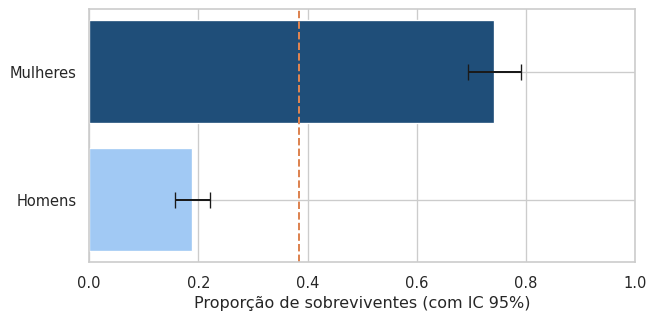

In [30]:
# Proporção de sobreviventes por sexo, com intervalo de confiança
low, high = proportion_confint(by_sex["sobreviventes"], by_sex["n"])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(["Homens", "Mulheres"], by_sex.loc[["male", "female"], "proporcao"],
        xerr=[(by_sex["proporcao"] - low)[["male", "female"]],
              (high - by_sex["proporcao"])[["male", "female"]]],
        color=["#A1C9F4", "#1F4E79"], capsize=6)
ax.axvline(p_pooled, color="#DD8452", linestyle="--")
ax.set(xlim=(0, 1), xlabel="Proporção de sobreviventes (com IC 95%)")
plt.tight_layout()
plt.show()

**Interpretação.** A barra das mulheres é quase quatro vezes a dos
homens, e os intervalos ficam muito longe um do outro e da taxa geral de
38% (linha tracejada). Se mulheres e homens tivessem a mesma chance de
sobreviver, 55 pontos percentuais de diferença seriam impossíveis por
acaso ($p < 0{,}001$). Rejeitamos $H_0$: a regra “mulheres e crianças
primeiro” aparece nos dados.

## Caso 7. Qui-quadrado de independência

> **Cenário**
>
> O mesmo historiador pergunta se a classe da passagem (`pclass`: 1ª, 2ª
> ou 3ª) teve relação com quem sobreviveu (`survived`), ou se a
> sobrevivência foi independente da classe.
>
> -   $H_0$: a sobrevivência não depende da classe. As variáveis são
>     independentes.
> -   $H_1$: a sobrevivência está associada à classe.

**Premissas do teste**

-   As duas variáveis são categóricas.
-   Observações independentes, cada uma contada em uma única célula da
    tabela.
-   Frequência esperada de pelo menos 5 em pelo menos 80% das células e
    nenhuma abaixo de 1. Quando essa condição falha, usa-se o teste
    exato de Fisher.

Com duas variáveis categóricas, os dados se resumem a uma **tabela de
contingência**, que conta os passageiros em cada combinação de classe e
desfecho:

In [31]:
# Tabela de contingência: classe por desfecho
observed = pd.crosstab(titanic["pclass"], titanic["survived"])

observed

O teste compara essas contagens observadas ($O$) com as que
**esperaríamos se a classe não tivesse nada a ver com a sobrevivência**
($E$). Sob independência, a contagem esperada de cada célula é o total
da linha vezes o total da coluna, dividido pelo total geral. A
estatística soma as discrepâncias padronizadas de todas as células:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
\qquad
\text{gl} = (\text{linhas} - 1)(\text{colunas} - 1)
$$

In [32]:
# Qui-quadrado, frequências esperadas e parcela de cada célula
case7 = stats.chi2_contingency(observed)

expected = pd.DataFrame(
    case7.expected_freq, index=observed.index, columns=observed.columns
)
contributions = (observed - expected) ** 2 / expected

print(f"χ² = {case7.statistic:.2f}, gl = {case7.dof}, p = {case7.pvalue:.1e}")
pd.concat({"esperado": expected, "(O−E)²/E": contributions}, axis=1).round(1)

χ² = 102.89, gl = 2, p = 4.5e-23

A estatística vale $\chi^2 \approx 102{,}9$, com 2 graus de liberdade e
$p < 0{,}001$. A menor frequência esperada é 70,6, e a condição de
aplicação é atendida com folga. As parcelas mostram **onde** está o
desvio: as maiores contribuições vêm da 1ª classe, que sobreviveu muito
mais que o esperado, e da 3ª, que sobreviveu muito menos.

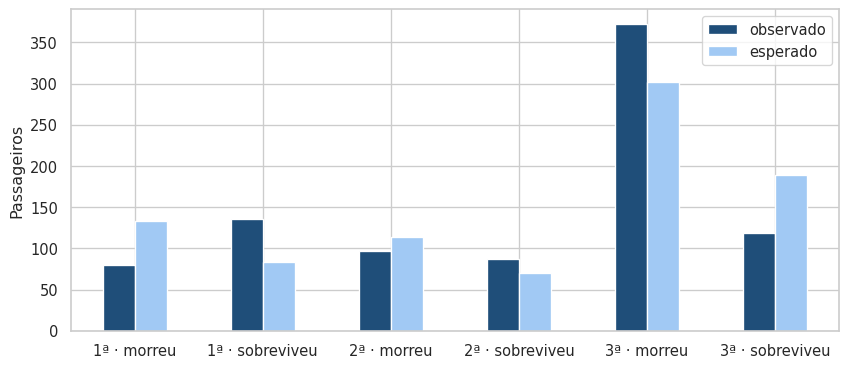

In [33]:
# Contagens observadas e esperadas sob independência
comparison = (
    pd.concat(
        {"observado": observed.stack(), "esperado": expected.stack()},
        axis=1,
    )
    .rename(index={0: "morreu", 1: "sobreviveu"}, level="survived")
)

fig, ax = plt.subplots(figsize=(9, 4))
comparison.plot.bar(ax=ax, color=["#1F4E79", "#A1C9F4"], rot=0)
ax.set_xticklabels([f"{c}ª · {d}" for c, d in comparison.index])
ax.set(xlabel="", ylabel="Passageiros")
plt.tight_layout()
plt.show()

**Interpretação.** Se classe e sobrevivência fossem independentes, as
barras escuras e claras teriam a mesma altura em cada par. Em vez disso,
a 1ª classe tem mais sobreviventes que o esperado (136 contra 83), e a
3ª classe tem muito menos (119 contra 188). A taxa de sobrevivência cai
de 63% na 1ª classe para 47% na 2ª e 24% na 3ª. Um desequilíbrio desse
tamanho seria praticamente impossível por acaso. Rejeitamos $H_0$: a
chance de sobreviver dependeu da classe de embarque. O V de Cramér, uma
medida da força da associação entre 0 e 1, vale cerca de 0,34, uma
associação moderada.

> **Z e qui-quadrado: o mesmo teste em tabelas 2 × 2**
>
> O teste *Z* do caso 6 também pode ser escrito como um qui-quadrado
> sobre a tabela sexo × sobrevivência, que tem 2 linhas e 2 colunas.
> Nesse caso particular, $Z^2 = \chi^2$: $16{,}2^2 \approx 263$. As duas
> abordagens dão o mesmo *p*-valor. O qui-quadrado tem a vantagem de se
> estender a tabelas maiores, como a da classe, com três linhas.

# 4. Quando as premissas falham

Se as premissas não se sustentam, troca-se o teste. As alternativas não
paramétricas trabalham, em geral, com **postos**: a posição de cada
valor na ordenação, em vez do valor em si. Isso as torna robustas a
assimetria e a valores atípicos.

| Paramétrico | Alternativa não paramétrica | Como funciona |
|------------------------|------------------------|------------------------|
| *t* de duas amostras | Mann-Whitney | Compara a soma dos postos dos dois grupos |
| *t* pareado | Wilcoxon dos postos sinalizados | Postos das diferenças, com sinal |
| ANOVA one-way | Kruskal-Wallis | Postos em três ou mais grupos |
| Pearson | Spearman | Correlação dos postos: capta relações monotônicas |
| Qualquer um | Permutação | Distribuição nula por embaralhamento (Aula 7) |

Amostras com menos de 10 observações, assimetria forte, valores atípicos
extremos ou escala ordinal são sinais para trocar o teste. O preço é
perder um pouco de poder nas situações em que as premissas valeriam.

# 5. Guia rápido

| Pergunta | Teste | Função |
|------------------------|------------------------|------------------------|
| A média difere de uma meta? | *t* de uma amostra | `stats.ttest_1samp` |
| Dois grupos independentes têm a mesma média? | *t* de Welch | `stats.ttest_ind(..., equal_var=False)` |
| A mesma unidade muda entre dois momentos? | *t* pareado | `stats.ttest_rel` |
| Três ou mais grupos têm a mesma média? | ANOVA + Tukey | `stats.f_oneway`, `stats.tukey_hsd` |
| Duas variáveis contínuas têm relação linear? | Pearson | `stats.pearsonr` |
| Dois grupos têm a mesma proporção? | *Z* de duas proporções | `proportions_ztest` |
| Duas variáveis categóricas são independentes? | Qui-quadrado | `stats.chi2_contingency` |
| Os dados são normais? | Q-Q plot + Shapiro-Wilk | `stats.probplot`, `stats.shapiro` |
| As variâncias são iguais? | Levene | `stats.levene` |

## Síntese

1.  **Paramétrico.** A distribuição nula vem da teoria (*t*, *F*, *Z* ou
    $\chi^2$), em troca de premissas.
2.  **Premissas.** Antes do teste, verifique normalidade,
    homocedasticidade e independência. O Q-Q plot e o Shapiro-Wilk se
    complementam.
3.  **Escolha.** O objetivo, a escala da variável e o delineamento
    determinam o teste.
4.  **Pareamento.** Ignorar o pareamento infla o erro-padrão: no
    `sleep`, o *p*-valor foi de 0,003 para 0,079.
5.  **Muitos grupos.** Com três ou mais grupos, use a ANOVA seguida de
    um teste post-hoc, nunca uma série de testes *t*.

# Perguntas para consolidar

## Pergunta 1: por que o pareamento mudou o resultado do `sleep`?

Os mesmos 20 números deram $p \approx 0{,}003$ no teste pareado e
$p \approx 0{,}079$ no teste para amostras independentes. Como isso é
possível?

> **Como pensar sobre isso**
>
> A diferença média é a mesma nas duas análises: 1,58 h. O que muda é o
> erro-padrão. No teste independente, ele inclui a variação entre
> pacientes, que é grande: alguns dormem bem com qualquer droga, outros
> não. No teste pareado, cada paciente serve de controle para si mesmo.
> A diferença $D$ elimina o nível de base de cada pessoa, e sobra apenas
> a variação do efeito da droga, que é pequena. Com um erro-padrão
> menor, a mesma diferença se distingue do acaso. Ignorar o pareamento
> não é apenas menos eficiente: é usar um teste cuja premissa de
> independência foi violada.

## Pergunta 2: não rejeitar $H_0$ no caso 1 prova que a frota cumpre a meta?

No caso 1, $p \approx 0{,}93$. O gestor pode afirmar que o consumo médio
da frota é de 20 mpg?

> **Como pensar sobre isso**
>
> Não. O teste mostra apenas que os dados são compatíveis com a meta. O
> intervalo de confiança, de 17,9 a 22,3 mpg, mostra que eles também são
> compatíveis com uma frota 2 mpg abaixo ou acima da meta. Com 32 carros
> e um desvio-padrão de 6 mpg, a precisão da média é limitada. Para
> afirmar que a frota está **dentro** de uma faixa aceitável, seria
> necessário outro desenho de teste, chamado teste de equivalência, ou
> uma amostra maior.

## Pergunta 3: o caso 6 precisava de um teste diferente do caso 7?

Os casos 6 e 7 usam a mesma base e a mesma resposta, a sobrevivência.
Por que um usa *Z* e o outro $\chi^2$?

> **Como pensar sobre isso**
>
> A diferença está na variável explicativa. No caso 6, ela é binária
> (sexo), e a pergunta é se duas proporções são iguais. No caso 7, ela
> tem três categorias (classe), e o teste *Z* de duas proporções não se
> aplica diretamente. Para tabelas 2 × 2, os dois testes são
> equivalentes: $Z^2 = \chi^2$. O qui-quadrado generaliza a comparação
> de proporções para qualquer número de categorias.

# Para casa

1.  Repita o caso 2 comparando a massa corporal das espécies Adelie e
    Gentoo. Verifique as premissas antes de escolher entre o *t*
    clássico e o de Welch.
2.  Aplique a ANOVA do caso 4 ao comprimento da **pétala**
    (`petal_length`). O que o teste de Levene indica? Compare o
    resultado com o teste de Kruskal-Wallis (`stats.kruskal`).
3.  No `mtcars`, calcule a correlação de Pearson e a de Spearman
    (`stats.spearmanr`) entre a potência (`hp`) e o consumo (`mpg`).
    Faça o gráfico de dispersão e discuta qual coeficiente descreve
    melhor a relação.
4.  No Titanic, teste se a taxa de sobrevivência difere entre os portos
    de embarque (`embarked`). Qual teste você escolheu, e por quê?
5.  Antes de considerar o notebook pronto, use Restart Kernel and Run
    All.

## Referências

1.  Bruce, P.; Bruce, A.; Gedeck, P. *Practical Statistics for Data
    Scientists*. 2. ed. O’Reilly, 2020.
2.  Student. The probable error of a mean. *Biometrika*, 6(1), 1-25,
    1908.
3.  Welch, B. L. The generalization of “Student’s” problem when several
    different population variances are involved. *Biometrika*, 34(1-2),
    28-35, 1947.
4.  Shapiro, S. S.; Wilk, M. B. An analysis of variance test for
    normality (complete samples). *Biometrika*, 52(3-4), 591-611, 1965.
5.  Fisher, R. A. The use of multiple measurements in taxonomic
    problems. *Annals of Eugenics*, 7(2), 179-188, 1936.
6.  Horst, A. M.; Hill, A. P.; Gorman, K. B. *palmerpenguins: Palmer
    Archipelago (Antarctica) penguin data*. R package, 2020.
7.  Henderson, H. V.; Velleman, P. F. Building multiple regression
    models interactively. *Biometrics*, 37(2), 391-411, 1981.